# Week 3 Day 2 — Dropout, Weight Decay
**Jul 14, 2026**

Every model so far has been small relative to its data, so overfitting hasn't been visible. Today: deliberately create it (tiny dataset, oversized model), watch it happen on a loss curve, then apply two different regularization techniques and compare what each actually does to that curve — not just whether the final number improves.

Scaffold as usual: TODO stubs, hints not formulas, self-check cells.

## Part 1: Watch a model overfit

Given. Only 40 training samples, a model with two 256-unit hidden layers (tens of thousands of parameters) — deliberately absurd capacity for this little data. No regularization. Train/val loss tracked every epoch.

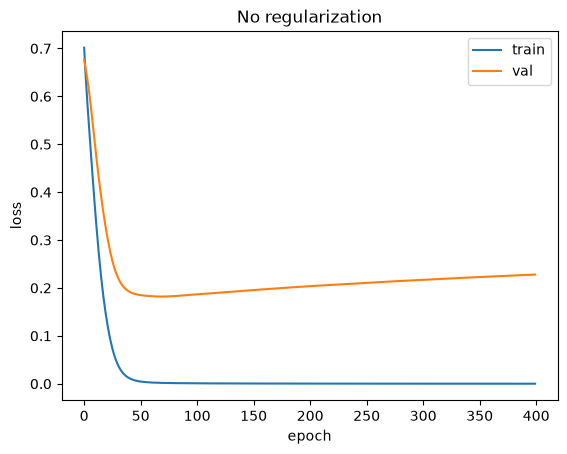

final: train 0.0001  val 0.2279
best val loss was 0.1820 at epoch 69


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
n_train, n_val, n_features = 40, 40, 10

X_train = torch.randn(n_train, n_features)
true_w = torch.randn(n_features)
y_train = (X_train @ true_w + 0.5 * torch.randn(n_train) > 0).float()

X_val = torch.randn(n_val, n_features)
y_val = (X_val @ true_w + 0.5 * torch.randn(n_val) > 0).float()

criterion = nn.BCEWithLogitsLoss()
n_epochs = 400

def make_baseline_model():
    return nn.Sequential(
        nn.Linear(n_features, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 1),
    )

def train_and_track(model, optimizer):
    train_losses, val_losses = [], []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train).squeeze(-1), y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val).squeeze(-1), y_val).item())
    return train_losses, val_losses

baseline_model = make_baseline_model()
baseline_opt = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)
baseline_train, baseline_val = train_and_track(baseline_model, baseline_opt)

plt.plot(baseline_train, label="train")
plt.plot(baseline_val, label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("No regularization")
plt.show()

print(f"final: train {baseline_train[-1]:.4f}  val {baseline_val[-1]:.4f}")
print(f"best val loss was {min(baseline_val):.4f} at epoch {baseline_val.index(min(baseline_val))}")

Train loss heads to ~0. Val loss bottoms out early, then climbs back up while train loss keeps falling — the model is memorizing the 40 training points rather than learning the underlying pattern. That growing gap *is* overfitting; it's not a training bug.

## Part 2: Weight decay

TODO: build a fresh model (same architecture as `make_baseline_model`) and an optimizer with `weight_decay` set to some positive value, then run it through `train_and_track` and compare its curve to the baseline's.

Mechanism, not code: `weight_decay` adds a penalty proportional to the *squared magnitude* of every weight directly into what gets minimized (this is L2 regularization) — practically, every optimizer step shrinks each weight slightly toward zero, in addition to whatever the data-driven gradient says to do. Large weights get pulled back harder than small ones. This directly fights the mechanism of overfitting here: memorizing 40 specific points tends to require some weights to grow large and specialized to those exact points.

Try a value like `1e-2` to start — `weight_decay` is itself a hyperparameter, feel free to try others once you see the baseline effect.

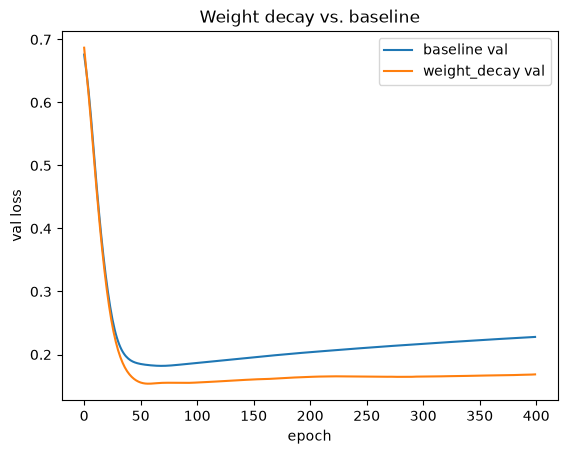

baseline final val: 0.2279
weight_decay final val: 0.1684


In [4]:
# TODO: wd_model = make_baseline_model()
wd_model = make_baseline_model()
# TODO: wd_opt = torch.optim.Adam(wd_model.parameters(), lr=1e-3, weight_decay=...)
wd_opt = torch.optim.Adam(wd_model.parameters(), lr=1e-3, weight_decay=1e-2)
# TODO: wd_train, wd_val = train_and_track(wd_model, wd_opt)
wd_train, wd_val = train_and_track(wd_model, wd_opt)

plt.plot(baseline_val, label="baseline val")
plt.plot(wd_val, label="weight_decay val")
plt.xlabel("epoch"); plt.ylabel("val loss"); plt.legend(); plt.title("Weight decay vs. baseline")
plt.show()

print(f"baseline final val: {baseline_val[-1]:.4f}")
print(f"weight_decay final val: {wd_val[-1]:.4f}")

## Part 3: Dropout

TODO: build a new model with `nn.Dropout(p)` layers inserted between each `Linear`+`ReLU` pair and the next `Linear` (i.e. after each activation, before the next layer's weights see the data). Train it with a plain optimizer (no `weight_decay`) and compare to both previous curves.

Mechanism: during training, `nn.Dropout(p)` independently zeroes each unit with probability `p` on every forward pass, and rescales the surviving units so their expected total magnitude is unchanged. The model can't rely on any single unit always being present, which discourages units from co-adapting to memorize specific training examples. During evaluation, dropout does *nothing* — all units pass through unchanged, no randomness. That behavior switch is entirely driven by `model.train()` vs `model.eval()`, which is the first time in this curriculum those calls actually change what a forward pass computes, rather than just being good practice.

Try `p=0.3` to start.

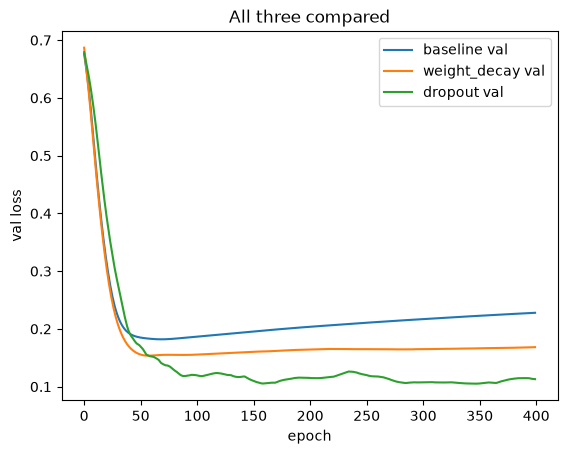

In [6]:
# TODO: dropout_model = nn.Sequential(nn.Linear(...), nn.ReLU(), nn.Dropout(...), nn.Linear(...), nn.ReLU(), nn.Dropout(...), nn.Linear(...))
dropout_model = nn.Sequential(
    nn.Linear(n_features, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 1),
)
# TODO: dropout_opt = torch.optim.Adam(dropout_model.parameters(), lr=1e-3)
dropout_opt = torch.optim.Adam(dropout_model.parameters(), lr=1e-3)

# TODO: dropout_train, dropout_val = train_and_track(dropout_model, dropout_opt)
dropout_train, dropout_val = train_and_track(dropout_model, dropout_opt)

plt.plot(baseline_val, label="baseline val")
plt.plot(wd_val, label="weight_decay val")
plt.plot(dropout_val, label="dropout val")
plt.xlabel("epoch"); plt.ylabel("val loss"); plt.legend(); plt.title("All three compared")
plt.show()

Don't expect dropout to fully flatten the curve the way `weight_decay` did here -- with only 40 training points against this much capacity, `p=0.3` slows overfitting rather than eliminating it. That's a realistic result, not a failed exercise; regularization strength is itself a hyperparameter, and this is exactly the kind of curve that tells you to push `p` higher or combine it with weight decay.

## Part 4: Prove `model.eval()` actually changes dropout's behavior

Given, once `dropout_model` exists. Same input, called twice in each mode.

In [7]:
x_probe = torch.randn(1, n_features)

dropout_model.train()
out1 = dropout_model(x_probe)
out2 = dropout_model(x_probe)
print("train() mode -- two calls on the same input, identical?", torch.equal(out1, out2))

dropout_model.eval()
out3 = dropout_model(x_probe)
out4 = dropout_model(x_probe)
print("eval() mode -- two calls on the same input, identical?", torch.equal(out3, out4))

train() mode -- two calls on the same input, identical? False
eval() mode -- two calls on the same input, identical? True


## Try yourself

1. Push `weight_decay` up an order of magnitude (e.g. `1e-1`). At what point does it start *hurting* train performance rather than just controlling val loss — i.e. underfitting?
2. Try `p=0.5` and `p=0.1` for dropout and compare curves. Is there a sweet spot for this specific dataset size?
3. Combine both: a dropout model trained with a `weight_decay`-set optimizer. Does combining them help more than either alone, here?
4. Rerun Part 1's baseline with `n_train` bumped up to 400 instead of 40, same model, same epoch count. Does the overfitting gap shrink even with zero regularization? What does that tell you about the actual cause of overfitting here — the model's capacity, or the data's size relative to it?